# WS/IS MB-OSA and Adaptive Slice-Width Mapping
This notebook analyzes the four canonical WS/IS × optical/digital accumulation structures. The first MRR operand is sliced to 1/2/4 bits, or uses the unsliced 8-bit Analog path. Physical MRR counts and total operand precision remain fixed. Accuracy is **NOT_MODELED**.

In [1]:
import json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
run_dir = Path(os.environ['OPTICALLOOP_MULTISLICE_RUN_DIR']).resolve()
artifacts = run_dir / 'artifacts-multislice'
metadata = json.loads((run_dir / 'run.json').read_text())
fixed = pd.read_csv(artifacts / 'fixed_width_summary.csv')
aswm = pd.read_csv(artifacts / 'aswm_summary.csv')
selections = pd.read_csv(artifacts / 'aswm_layer_selections.csv')
comparison = pd.read_csv(artifacts / 'sensitivity_comparison.csv')
checks = pd.read_csv(artifacts / 'validation.csv')
metadata['tier'], metadata['successful_jobs'], metadata['expected_jobs']

('full', 42240, 42240)

## Reproduced configuration and coverage

In [2]:
manifest = metadata['manifest']
configuration = pd.DataFrame(manifest['architectures']).set_index('name')
coverage = fixed.groupby(['network', 'variant', 'architecture']).layers.max().unstack('variant')
display(configuration)
display(coverage)
assert metadata['successful_jobs'] == metadata['expected_jobs']
assert checks.loc[checks.status == 'FAIL'].empty

,candidate,cols,pes,rows,tiles
name,,,,,
deap_high_channel,False,9,1,113,1
deap_wide_kernel,False,100,1,12,1
compact_4x4,True,4,64,4,1
c4_r8,True,4,32,8,1
c4_r16,True,4,16,16,1
c4_r32,True,4,8,32,1
c8_r4,True,8,32,4,1
paper_optimum_8x8,True,8,16,8,1
c8_r16,True,8,8,16,1


variant                               is_no_osa_1  is_no_osa_8  is_osa_1  \
network            architecture                                            
alexnet            c4_r16                       8            8         8   
                   c4_r32                       8            8         8   
                   c4_r8                        8            8         8   
                   c8_r16                       8            8         8   
                   c8_r32                       8            8         8   
                   c8_r4                        8            8         8   
                   compact_4x4                  8            8         8   
                   deap_high_channel            8            8         8   
                   deap_wide_kernel             8            8         8   
                   paper_optimum_8x8            8            8         8   
gpt2_medium        c4_r16                     145          145       145   
                   c4_r32                     145          145       145   
                   c4_r8                      145          145       145   
                   c8_r16                     145          145       145   
                   c8_r32                     145          145       145   
                   c8_r4                      145          145       145   
                   compact_4x4                145          145       145   
                   deap_high_channel          145          145       145   
                   deap_wide_kernel           145          145       145   
                   paper_optimum_8x8          145          145       145   
mobilenet_v3       c4_r16                      64           64        64   
                   c4_r32                      64           64        64   
                   c4_r8                       64           64        64   
                   c8_r16                      64           64        64   
                   c8_r32                      64           64        64   
                   c8_r4                       64           64        64   
                   compact_4x4                 64           64        64   
                   deap_high_channel           64           64        64   
                   deap_wide_kernel            64           64        64   
                   paper_optimum_8x8           64           64        64   
resnet18           c4_r16                      21           21        21   
                   c4_r32                      21           21        21   
                   c4_r8                       21           21        21   
                   c8_r16                      21           21        21   
                   c8_r32                      21           21        21   
                   c8_r4                       21           21        21   
                   compact_4x4                 21           21        21   
                   deap_high_channel           21           21        21   
                   deap_wide_kernel            21           21        21   
                   paper_optimum_8x8           21           21        21   
vgg16              c4_r16                      16           16        16   
                   c4_r32                      16           16        16   
                   c4_r8                       16           16        16   
                   c8_r16                      16           16        16   
                   c8_r32                      16           16        16   
                   c8_r4                       16           16        16   
                   compact_4x4                 16           16        16   
                   deap_high_channel           16           16        16   
                   deap_wide_kernel            16           16        16   
                   paper_optimum_8x8           16           16        16   
vision_transformer c4_r16                      9

## Validation and accuracy boundary

In [3]:
display(checks)
assert fixed.accuracy_status.eq('NOT_MODELED').all()
assert aswm.accuracy_status.eq('NOT_MODELED').all()

,check,severity,status,detail
0,job_coverage,ERROR,PASS,42240/42240
1,no_duplicate_jobs,ERROR,PASS,unique=42240
2,exact_expected_jobs,ERROR,PASS,"missing=0, unexpected=0"
3,no_failed_job_results,ERROR,PASS,"result_files=42240, failed=0"
4,supported_slice_widths,ERROR,PASS,"[np.int64(1), np.int64(2), np.int64(4), np.int..."
5,temporal_slice_counts,ERROR,PASS,expected 8/4/2/1
6,temporal_accumulation_counts,ERROR,PASS,expected 7/3/1/0
7,accuracy_not_modeled,ERROR,PASS,NOT_MODELED
8,accumulation_component_selection,ERROR,PASS,"optical=delay_line, digital=digital_shift_add,..."
9,native_mapping_stationarity,ERROR,PASS,WS accumulator traverses X; IS accumulator tra...


## Primary 5.2 pJ/bit model

In [4]:
primary_fixed = fixed[(fixed.energy_model == 'linear_bit') & (fixed.optical_loss_db_per_stage == 0)]
primary_aswm = aswm[(aswm.energy_model == 'linear_bit') & (aswm.optical_loss_db_per_stage == 0)]
headline = comparison[(comparison.energy_model == 'linear_bit') & (comparison.optical_loss_db_per_stage == 0)]
display(headline.sort_values(['mapping', 'network', 'edp_j_s']))
display(primary_fixed.sort_values(['stationarity', 'network', 'front_mrr_slice_bits']))

,network,architecture,energy_model,optical_loss_db_per_stage,mapping,stationarity,layers,energy_j,latency_s,edp_j_s,frontier_states,accuracy,accuracy_status,best_fixed_stationarity,best_fixed_slice_bits,fixed_edp_j_s,aswm_reduction_vs_best_fixed
813,alexnet,c8_r32,linear_bit,0.0,ASWM-IS,IS,8,1.453183,0.029039,0.042198,93,NaN,NOT_MODELED,IS,4,0.042198,0.000000e+00
435,alexnet,c4_r32,linear_bit,0.0,ASWM-IS,IS,8,2.995758,0.024385,0.073051,110,NaN,NOT_MODELED,IS,4,0.073051,0.000000e+00
840,alexnet,c8_r16,linear_bit,0.0,ASWM-IS,IS,8,2.571221,0.029039,0.074665,93,NaN,NOT_MODELED,IS,4,0.074665,-2.220446e-16
786,alexnet,c4_r16,linear_bit,0.0,ASWM-IS,IS,8,6.413410,0.024386,0.156395,110,NaN,NOT_MODELED,IS,4,0.156395,-4.440892e-16
858,alexnet,paper_optimum_8x8,linear_bit,0.0,ASWM-IS,IS,8,6.097665,0.029143,0.177702,95,NaN,NOT_MODELED,IS,4,0.177702,-2.220446e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,vision_transformer,c4_r32,linear_bit,0.0,Mixed-1bit,MIXED,98,39.774827,1.685766,67.051057,2,NaN,NOT_MODELED,WS,1,67.051057,1.110223e-15
1371,vision_transformer,c4_r16,linear_bit,0.0,Mixed-1bit,MIXED,98,41.314535,1.685780,69.647203,1,NaN,NOT_MODELED,WS,1,69.647203,1.443290e-15
1416,vision_transformer,c4_r8,linear_bit,0.0,Mixed-1bit,MIXED,98,49.152253,1.685705,82.856215,1,NaN,NOT_MODELED,WS,1,82.856215,5.551115e-16
1515,vision_transformer,c8_r4,linear_bit,0.0,Mixed-1bit,MIXED,98,49.223750,1.685705,82.976737,1,NaN,NOT_MODELED,WS,1,82.976737,1.665335e-15


,network,architecture,variant,stationarity,accumulation,sliced_operand,front_mrr_slice_bits,energy_model,optical_loss_db_per_stage,accuracy_status,layers,energy_j,latency_s,edp_j_s
2334,alexnet,compact_4x4,is_no_osa_1,IS,digital,weight,1,linear_bit,0.0,NOT_MODELED,8,35.965450,0.098807,3.553655
3522,alexnet,c4_r16,is_osa_1,IS,optical,weight,1,linear_bit,0.0,NOT_MODELED,8,5.025552,0.097543,0.490206
3828,alexnet,paper_optimum_8x8,is_no_osa_1,IS,digital,weight,1,linear_bit,0.0,NOT_MODELED,8,4.806195,0.116571,0.560261
4161,alexnet,deap_high_channel,is_osa_1,IS,optical,weight,1,linear_bit,0.0,NOT_MODELED,8,1.460563,0.167232,0.244252
4458,alexnet,c8_r32,is_osa_1,IS,optical,weight,1,linear_bit,0.0,NOT_MODELED,8,1.698904,0.116154,0.197335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3027,vision_transformer,c8_r32,ws_no_osa_8,WS,none,input,8,linear_bit,0.0,NOT_MODELED,98,22.539385,0.210721,4.749517
3081,vision_transformer,c4_r32,ws_osa_8,WS,none,input,8,linear_bit,0.0,NOT_MODELED,98,44.251677,0.210721,9.324747
3486,vision_transformer,compact_4x4,ws_osa_8,WS,none,input,8,linear_bit,0.0,NOT_MODELED,98,249.956790,0.210713,52.669186
3729,vision_transformer,paper_optimum_8x8,ws_no_osa_8,WS,none,input,8,linear_bit,0.0,NOT_MODELED,98,66.624154,0.210713,14.038586


## Energy-delay and slice selections

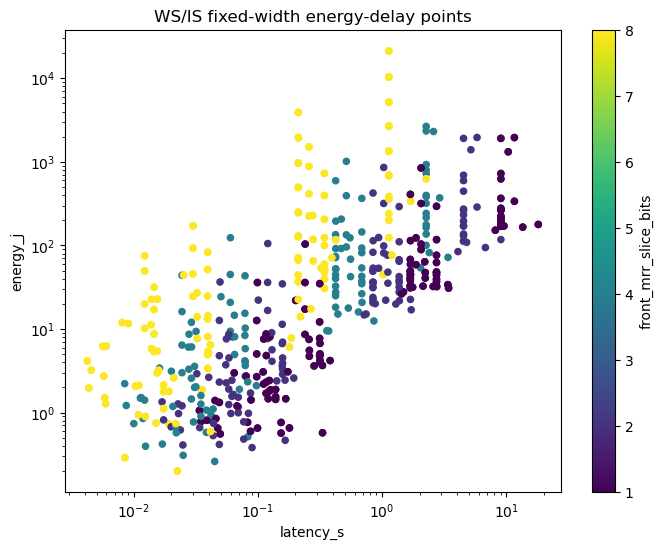

front_mrr_slice_bits        1   2     4
mapping    stationarity                
ASWM-IS    IS               0  27  2789
ASWM-WS    WS               0   0  2816
Joint-ASWM IS               0   0    61
           WS               0   0  2755
Mixed-1bit IS              66   0     0
           WS            2750   0     0

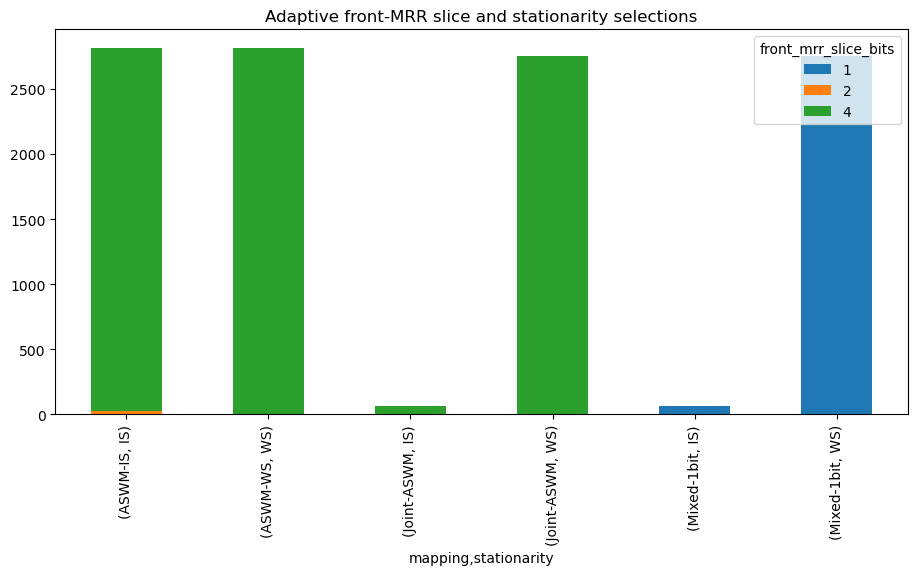

In [5]:
ax = primary_fixed.plot.scatter(x='latency_s', y='energy_j', c='front_mrr_slice_bits', colormap='viridis', logx=True, logy=True, figsize=(8, 6))
ax.set_title('WS/IS fixed-width energy-delay points')
plt.show()
primary_selections = selections[(selections.energy_model == 'linear_bit') & (selections.optical_loss_db_per_stage == 0)]
selection_counts = primary_selections.groupby(['mapping', 'stationarity', 'front_mrr_slice_bits']).size().unstack(fill_value=0)
display(selection_counts)
selection_counts.plot.bar(stacked=True, figsize=(11, 5), title='Adaptive front-MRR slice and stationarity selections')
plt.show()

## Sensitivity boundary
The optimistic constant-symbol and conservative Walden DAC models, together with 0/0.5/1 dB optical-loss compensation per delay stage, are modeling sensitivities—not measured accuracy results.

In [6]:
sensitivity = aswm.groupby(['energy_model', 'optical_loss_db_per_stage']).edp_j_s.agg(['min', 'median', 'max'])
display(sensitivity)

min     median  \
energy_model               optical_loss_db_per_stage                        
conservative_walden        0.0                        0.006595  13.974503   
                           0.5                        0.006596  13.974808   
                           1.0                        0.006596  13.975151   
linear_bit                 0.0                        0.003846   7.543559   
                           0.5                        0.003846   7.543864   
                           1.0                        0.003846   7.544206   
optimistic_constant_symbol 0.0                        0.003096   5.326351   
                           0.5                        0.003096   5.326876   
                           1.0                        0.003096   5.327466   

                                                              max  
energy_model               optical_loss_db_per_stage               
conservative_walden        0.0                        9967.578656  
                           0.5                        9967.638824  
                           1.0                        9967.706333  
linear_bit                 0.0                        6015.209814  
                           0.5                        6015.269982  
                           1.0                        6015.337491  
optimistic_constant_symbol 0.0                        4937.291039  
                           0.5                        4937.351207  
                           1.0                        4937.418716